## Individual Homework


### Imports


In [53]:
# 1. Imports
import gzip
import os
import random
import shutil
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GCNConv, SAGEConv
from torch_geometric.utils import from_networkx


### Graph Loading


In [54]:
os.makedirs("data", exist_ok=True)

urls = {
    "edges": "https://snap.stanford.edu/data/email-Eu-core.txt.gz",
    "labels": "https://snap.stanford.edu/data/email-Eu-core-department-labels.txt.gz",
}

for name, url in urls.items():
    gz_path = f"data/{name}.gz"
    txt_path = f"data/{name}.txt"

    if not os.path.exists(txt_path):
        urllib.request.urlretrieve(url, gz_path)
        with gzip.open(gz_path, "rb") as f_in, open(txt_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)


In [55]:
edges = pd.read_csv(
    "data/edges.txt",
    sep=" ",
    header=None,
    names=["source", "target"],
)
labels = pd.read_csv(
    "data/labels.txt",
    sep=" ",
    header=None,
    names=["node", "department"],
)

print(edges.head())
print(labels.head())

print("Nodes:", labels["node"].nunique())
print("Edges:", len(edges))
print("Classes:", labels["department"].nunique())


   source  target
0       0       1
1       2       3
2       2       4
3       5       6
4       5       7
   node  department
0     0           1
1     1           1
2     2          21
3     3          21
4     4          21
Nodes: 1005
Edges: 25571
Classes: 42


### Graph Building And Calculating Statistics


In [56]:
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.DiGraph(),
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is directed:", G.is_directed())
print("Is weakly connected:", nx.is_weakly_connected(G))
print("Number of weakly connected components:", nx.number_weakly_connected_components(G))
print("Number of strongly connected components:", nx.number_strongly_connected_components(G))

largest_cc = max(nx.weakly_connected_components(G), key=len)
subG = G.subgraph(list(largest_cc)).to_undirected()
centrality = nx.degree_centrality(G)

print("Largest component size:", len(largest_cc))
print("Approx diameter:", nx.diameter(subG))
print(
    "Top 5 nodes by centrality:",
    sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5],
)


Number of nodes: 1005
Number of edges: 25571
Is directed: True
Is weakly connected: False
Number of weakly connected components: 20
Number of strongly connected components: 203
Largest component size: 986
Approx diameter: 7
Top 5 nodes by centrality: [(160, 0.5438247011952191), (121, 0.37749003984063745), (107, 0.3715139442231076), (62, 0.36752988047808766), (86, 0.3545816733067729)]


In [57]:
degrees = dict(G.degree())
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print("Average degree:", sum(degrees.values()) / len(degrees))
print("Average in-degree:", sum(in_degrees.values()) / len(in_degrees))
print("Average out-degree:", sum(out_degrees.values()) / len(out_degrees))

G_undirected = G.to_undirected()

print("Average clustering coefficient:", nx.average_clustering(G_undirected))
print("Density:", nx.density(G))


Average degree: 50.88756218905473
Average in-degree: 25.443781094527363
Average out-degree: 25.443781094527363
Average clustering coefficient: 0.3993549664221539
Density: 0.025342411448732432


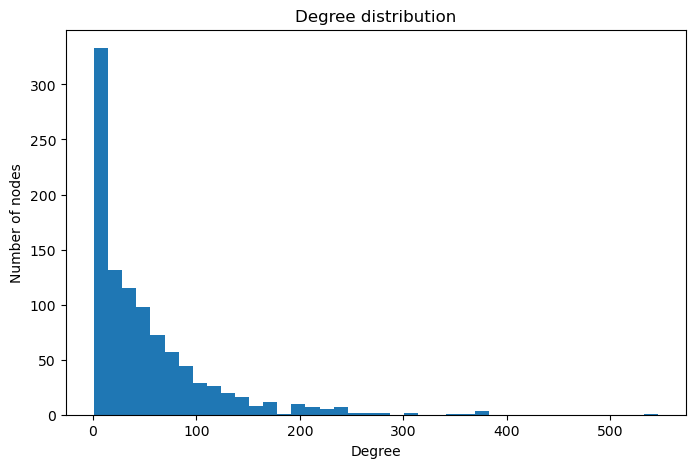

In [58]:
degree_values = list(degrees.values())

plt.figure(figsize=(8, 5))
plt.hist(degree_values, bins=40)
plt.title("Degree distribution")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.show()


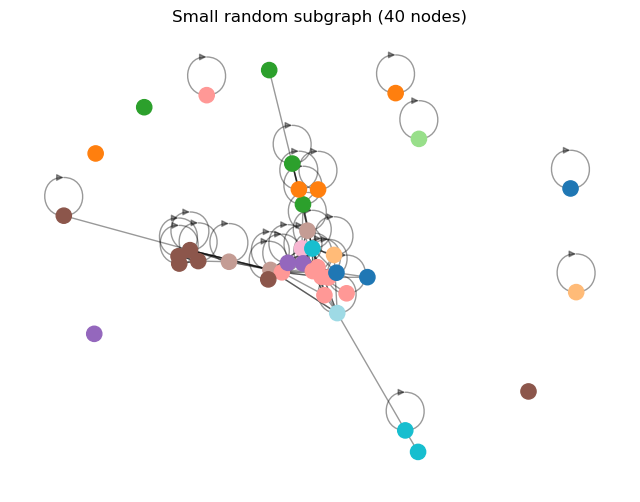

In [59]:
sample_nodes = random.sample(list(G.nodes()), 40)
subG = G.subgraph(sample_nodes).copy()

node_to_label = dict(zip(labels["node"], labels["department"]))
sub_node_colors = [node_to_label.get(node, -1) for node in subG.nodes()]

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subG, seed=42)

nx.draw_networkx_nodes(
    subG,
    pos,
    node_size=120,
    node_color=sub_node_colors,
    cmap=plt.cm.tab20,
)
nx.draw_networkx_edges(subG, pos, alpha=0.4, arrows=False)

plt.title("Small random subgraph (40 nodes)")
plt.axis("off")
plt.show()


In [60]:
all_nodes = sorted(labels["node"].unique())
node_id_to_idx = {node_id: idx for idx, node_id in enumerate(all_nodes)}

edge_index = torch.tensor(
    [
        [node_id_to_idx[src], node_id_to_idx[dst]]
        for src, dst in edges.values
    ],
    dtype=torch.long,
).t().contiguous()

labels_sorted = labels.sort_values("node")
y = torch.tensor(labels_sorted["department"].values, dtype=torch.long)

print("edge_index shape:", edge_index.shape)
print("y shape:", y.shape)
print("Number of classes:", y.max().item() + 1)


edge_index shape: torch.Size([2, 25571])
y shape: torch.Size([1005])
Number of classes: 42


In [61]:
num_nodes = len(all_nodes)

in_deg = torch.zeros(num_nodes, dtype=torch.float)
out_deg = torch.zeros(num_nodes, dtype=torch.float)

for src, dst in edges.values:
    out_deg[node_id_to_idx[src]] += 1
    in_deg[node_id_to_idx[dst]] += 1

total_deg = in_deg + out_deg
x = torch.stack([in_deg, out_deg, total_deg], dim=1)

x = (x - x.mean(dim=0)) / (x.std(dim=0) + 1e-8)

print("x shape:", x.shape)


x shape: torch.Size([1005, 3])


In [62]:
class_counts = Counter(y.numpy())
valid_classes = sorted(cls for cls, count in class_counts.items() if count >= 5)
class_to_idx = {cls: idx for idx, cls in enumerate(valid_classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

y_mapped = torch.full_like(y, fill_value=-1)
for original_class, mapped_class in class_to_idx.items():
    y_mapped[y == original_class] = mapped_class

valid_node_mask = y_mapped >= 0
valid_indices = valid_node_mask.nonzero(as_tuple=True)[0]

print("Original nodes:", len(y))
print("Remaining nodes:", len(valid_indices))
print("Original classes:", len(class_counts))
print("Remaining classes:", len(valid_classes))


Original nodes: 1005
Remaining nodes: 987
Original classes: 42
Remaining classes: 35


In [63]:
train_idx, temp_idx = train_test_split(
    valid_indices.numpy(),
    test_size=0.4,
    random_state=42,
    stratify=y_mapped[valid_indices].numpy(),
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=y_mapped[temp_idx].numpy(),
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data = Data(
    x=x,
    edge_index=edge_index,
    y=y_mapped,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

print(data)
print("Train nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())


Data(x=[1005, 3], edge_index=[2, 25571], y=[1005], train_mask=[1005], val_mask=[1005], test_mask=[1005])
Train nodes: 592
Validation nodes: 197
Test nodes: 198


### Model Training And Evaluation


In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_features = data.num_node_features
num_classes = int(data.y.max().item()) + 1

print("Device:", device)
print("Number of features:", num_features)
print("Number of classes:", num_classes)


Device: cpu
Number of features: 3
Number of classes: 35


In [65]:
class GNN(torch.nn.Module):
    def __init__(
        self,
        model_name,
        in_channels,
        hidden_channels,
        out_channels,
        dropout=0.5,
        heads=4,
    ):
        super().__init__()
        self.model_name = model_name
        self.dropout = dropout

        if model_name == "GCN":
            self.conv1 = GCNConv(in_channels, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, out_channels)
        elif model_name == "GraphSAGE":
            self.conv1 = SAGEConv(in_channels, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, out_channels)
        elif model_name == "GAT":
            self.conv1 = GATConv(
                in_channels,
                hidden_channels,
                heads=heads,
                dropout=dropout,
            )
            self.conv2 = GATConv(
                hidden_channels * heads,
                out_channels,
                heads=1,
                concat=False,
                dropout=dropout,
            )
        else:
            raise ValueError(f"Unknown model: {model_name}")

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


In [66]:
def evaluate_model(model, graph_data):
    model.eval()
    with torch.no_grad():
        logits = model(graph_data.x, graph_data.edge_index)
        pred = logits.argmax(dim=1)

    scores = {}
    for split_name, mask in {
        "train": graph_data.train_mask,
        "val": graph_data.val_mask,
        "test": graph_data.test_mask,
    }.items():
        y_true = graph_data.y[mask].detach().cpu().numpy()
        y_pred = pred[mask].detach().cpu().numpy()
        scores[f"{split_name}_accuracy"] = accuracy_score(y_true, y_pred)
        scores[f"{split_name}_f1_macro"] = f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        )

    return scores, pred.detach().cpu()


def train_model(
    model_name,
    hidden_channels=32,
    lr=0.01,
    weight_decay=5e-4,
    dropout=0.5,
    heads=4,
    epochs=150,
    patience=30,
):
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(42)

    graph_data = data.clone().to(device)
    model = GNN(
        model_name=model_name,
        in_channels=num_features,
        hidden_channels=hidden_channels,
        out_channels=num_classes,
        dropout=dropout,
        heads=heads,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_state = None
    best_val_loss = float("inf")
    best_epoch = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(graph_data.x, graph_data.edge_index)
        loss = torch.nn.functional.cross_entropy(
            logits[graph_data.train_mask],
            graph_data.y[graph_data.train_mask],
        )
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(graph_data.x, graph_data.edge_index)
            val_loss = torch.nn.functional.cross_entropy(
                val_logits[graph_data.val_mask],
                graph_data.y[graph_data.val_mask],
            )

        scores, _ = evaluate_model(model, graph_data)
        history.append(
            {
                "epoch": epoch,
                "loss": float(loss.item()),
                "val_loss": float(val_loss.item()),
                **scores,
            }
        )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        if epoch - best_epoch >= patience:
            break

    model.load_state_dict(best_state)
    final_scores, pred = evaluate_model(model, graph_data)

    return {
        "model": model_name,
        "hidden_channels": hidden_channels,
        "lr": lr,
        "weight_decay": weight_decay,
        "dropout": dropout,
        "heads": heads if model_name == "GAT" else None,
        "best_epoch": best_epoch,
        **final_scores,
        "trained_model": model.cpu(),
        "predictions": pred,
        "history": pd.DataFrame(history),
    }


### Architecture Comparison And Hyperparameter Search


In [67]:
search_space = [
    {
        "model_name": model_name,
        "hidden_channels": hidden_channels,
        "lr": lr,
        "dropout": dropout,
        "heads": heads,
    }
    for model_name in ["GCN", "GraphSAGE", "GAT"]
    for hidden_channels in [16, 32]
    for lr in [0.01, 0.005]
    for dropout in [0.3, 0.5]
    for heads in ([2, 4] if model_name == "GAT" else [1])
]

results = []
trained_runs = []

for params in search_space:
    run = train_model(
        **params,
        weight_decay=5e-4,
        epochs=150,
        patience=30,
    )
    run["run_id"] = len(trained_runs)
    trained_runs.append(run)
    results.append(
        {
            key: value
            for key, value in run.items()
            if key not in {"trained_model", "predictions", "history"}
        }
    )
    print(
        f"{run['model']:9s} | hidden={run['hidden_channels']:2d} "
        f"lr={run['lr']:.3f} dropout={run['dropout']:.1f} "
        f"val_acc={run['val_accuracy']:.3f} test_acc={run['test_accuracy']:.3f}"
    )

results_df = pd.DataFrame(results).sort_values(
    by=["val_accuracy", "val_f1_macro"],
    ascending=False,
).reset_index(drop=True)

results_df


GCN       | hidden=16 lr=0.010 dropout=0.3 val_acc=0.157 test_acc=0.187
GCN       | hidden=16 lr=0.010 dropout=0.5 val_acc=0.157 test_acc=0.187
GCN       | hidden=16 lr=0.005 dropout=0.3 val_acc=0.157 test_acc=0.187
GCN       | hidden=16 lr=0.005 dropout=0.5 val_acc=0.157 test_acc=0.192
GCN       | hidden=32 lr=0.010 dropout=0.3 val_acc=0.168 test_acc=0.187
GCN       | hidden=32 lr=0.010 dropout=0.5 val_acc=0.162 test_acc=0.187
GCN       | hidden=32 lr=0.005 dropout=0.3 val_acc=0.152 test_acc=0.172
GCN       | hidden=32 lr=0.005 dropout=0.5 val_acc=0.157 test_acc=0.177
GraphSAGE | hidden=16 lr=0.010 dropout=0.3 val_acc=0.183 test_acc=0.192
GraphSAGE | hidden=16 lr=0.010 dropout=0.5 val_acc=0.173 test_acc=0.192
GraphSAGE | hidden=16 lr=0.005 dropout=0.3 val_acc=0.168 test_acc=0.192
GraphSAGE | hidden=16 lr=0.005 dropout=0.5 val_acc=0.168 test_acc=0.197
GraphSAGE | hidden=32 lr=0.010 dropout=0.3 val_acc=0.183 test_acc=0.232
GraphSAGE | hidden=32 lr=0.010 dropout=0.5 val_acc=0.198 test_ac

,model,hidden_channels,lr,weight_decay,dropout,heads,best_epoch,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,test_accuracy,test_f1_macro,run_id
0,GAT,16,0.010,0.0005,0.3,4.0,150,0.226351,0.060534,0.218274,0.048399,0.212121,0.040998,17
1,GraphSAGE,32,0.010,0.0005,0.5,NaN,139,0.236486,0.130258,0.197970,0.095129,0.196970,0.049152,13
2,GraphSAGE,32,0.005,0.0005,0.3,NaN,142,0.224662,0.116558,0.192893,0.096018,0.202020,0.049302,14
3,GAT,32,0.010,0.0005,0.3,4.0,144,0.207770,0.045103,0.187817,0.044306,0.217172,0.043880,25
4,GraphSAGE,32,0.010,0.0005,0.3,NaN,137,0.268581,0.176120,0.182741,0.091457,0.232323,0.086078,12
5,GraphSAGE,16,0.010,0.0005,0.3,NaN,148,0.219595,0.108263,0.182741,0.073115,0.191919,0.043152,8
6,GraphSAGE,32,0.005,0.0005,0.5,NaN,143,0.199324,0.072298,0.182741,0.055455,0.202020,0.046463,15
7,GraphSAGE,16,0.010,0.0005,0.5,NaN,148,0.195946,0.070979,0.172589,0.036342,0.191919,0.038014,9
8,GAT,32,0.005,0.0005,0.3,4.0,149,0.190878,0.025249,0.172589,0.021424,0.191919,0.024793,29
9,GraphSAGE,16,0.005,0.0005,0.3,NaN,150,0.206081,0.073350,0.167513,0.043107,0.191919,0.043590,10


In [72]:
best_config = results_df.iloc[0]
best_run = trained_runs[int(best_config["run_id"])]

print("Best configuration:")
print(best_config)

summary_columns = [
    "model",
    "hidden_channels",
    "lr",
    "dropout",
    "heads",
    "best_epoch",
    "train_accuracy",
    "train_f1_macro",
    "test_accuracy",
    "test_f1_macro",
]

results_df[summary_columns].head(10)


Best configuration:
model                   GAT
hidden_channels          16
lr                     0.01
weight_decay         0.0005
dropout                 0.3
heads                   4.0
best_epoch              150
train_accuracy     0.226351
train_f1_macro     0.060534
val_accuracy       0.218274
val_f1_macro       0.048399
test_accuracy      0.212121
test_f1_macro      0.040998
run_id                   17
Name: 0, dtype: object


,model,hidden_channels,lr,dropout,heads,best_epoch,train_accuracy,train_f1_macro,test_accuracy,test_f1_macro
0,GAT,16,0.010,0.3,4.0,150,0.226351,0.060534,0.212121,0.040998
1,GraphSAGE,32,0.010,0.5,NaN,139,0.236486,0.130258,0.196970,0.049152
2,GraphSAGE,32,0.005,0.3,NaN,142,0.224662,0.116558,0.202020,0.049302
3,GAT,32,0.010,0.3,4.0,144,0.207770,0.045103,0.217172,0.043880
4,GraphSAGE,32,0.010,0.3,NaN,137,0.268581,0.176120,0.232323,0.086078
5,GraphSAGE,16,0.010,0.3,NaN,148,0.219595,0.108263,0.191919,0.043152
6,GraphSAGE,32,0.005,0.5,NaN,143,0.199324,0.072298,0.202020,0.046463
7,GraphSAGE,16,0.010,0.5,NaN,148,0.195946,0.070979,0.191919,0.038014
8,GAT,32,0.005,0.3,4.0,149,0.190878,0.025249,0.191919,0.024793
9,GraphSAGE,16,0.005,0.3,NaN,150,0.206081,0.073350,0.191919,0.043590


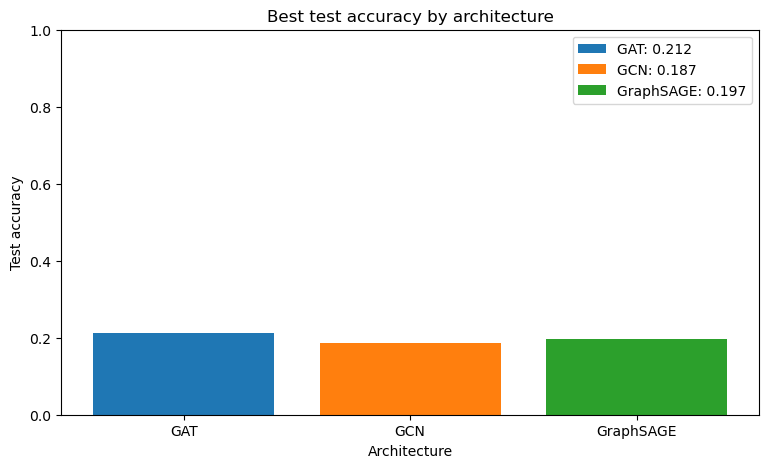

In [73]:
plt.figure(figsize=(9, 5))

for model_name, group in results_df.groupby("model"):
    best_by_model = group.sort_values(
        by=["val_accuracy", "val_f1_macro"],
        ascending=False,
    ).iloc[0]
    plt.bar(
        model_name,
        best_by_model["test_accuracy"],
        label=f"{model_name}: {best_by_model['test_accuracy']:.3f}",
    )

plt.title("Best test accuracy by architecture")
plt.xlabel("Architecture")
plt.ylabel("Test accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()


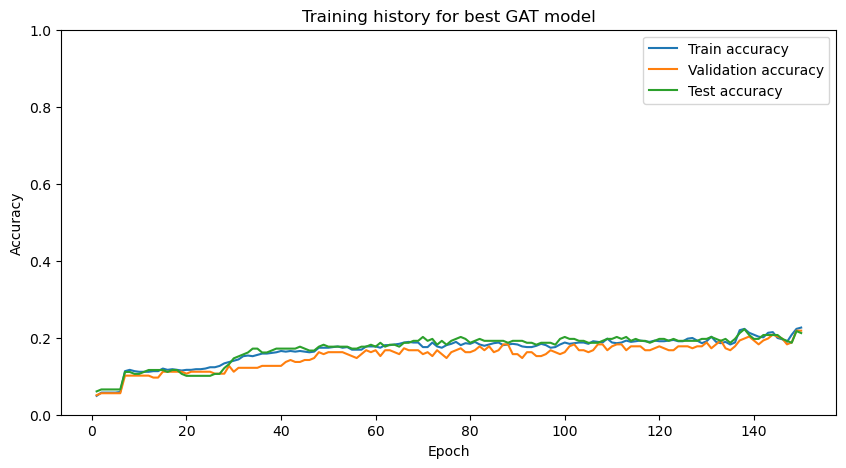

In [74]:
history = best_run["history"]

plt.figure(figsize=(10, 5))
plt.plot(history["epoch"], history["train_accuracy"], label="Train accuracy")
plt.plot(history["epoch"], history["val_accuracy"], label="Validation accuracy")
plt.plot(history["epoch"], history["test_accuracy"], label="Test accuracy")
plt.title(f"Training history for best {best_run['model']} model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()


### Prediction Visualization On A Subgraph


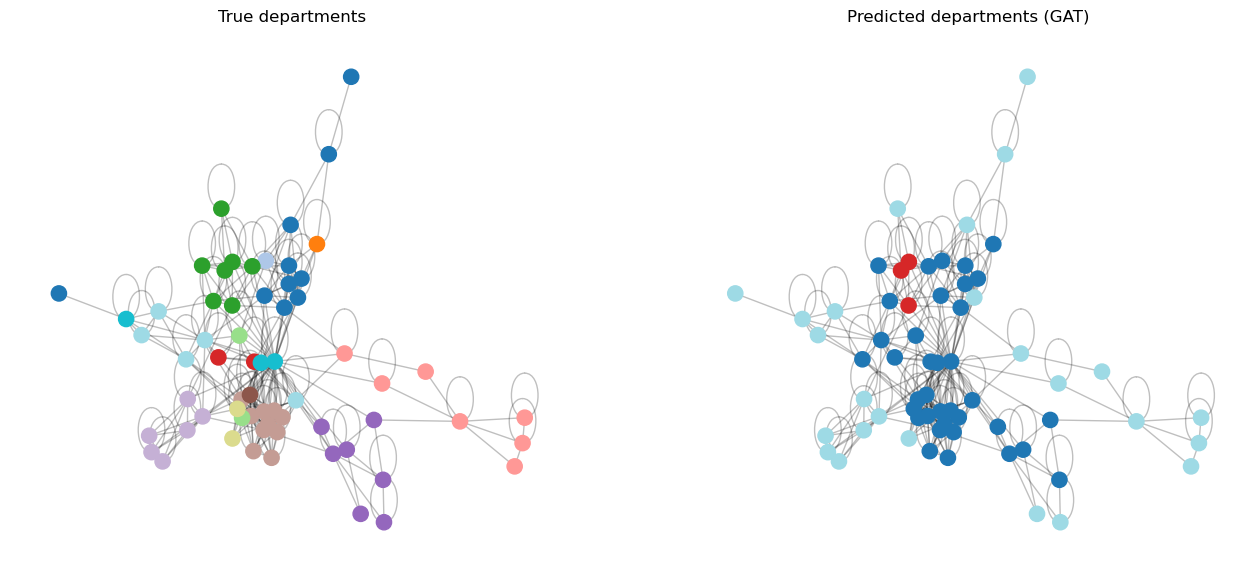

In [75]:
predictions = best_run["predictions"]
idx_to_node_id = {idx: node_id for node_id, idx in node_id_to_idx.items()}

test_indices = test_mask.nonzero(as_tuple=True)[0].tolist()
random.seed(42)
center_indices = random.sample(test_indices, min(12, len(test_indices)))
center_nodes = [idx_to_node_id[idx] for idx in center_indices]

visual_nodes = set(center_nodes)
for node in center_nodes:
    visual_nodes.update(list(G.predecessors(node))[:4])
    visual_nodes.update(list(G.successors(node))[:4])

visual_nodes = list(visual_nodes)[:90]
visual_subgraph = G.subgraph(visual_nodes).to_undirected().copy()
pos = nx.spring_layout(visual_subgraph, seed=42)

true_colors = [
    class_to_idx.get(node_to_label.get(node, -1), -1)
    for node in visual_subgraph.nodes()
]
pred_colors = [
    predictions[node_id_to_idx[node]].item()
    if node_id_to_idx[node] in valid_indices.tolist()
    else -1
    for node in visual_subgraph.nodes()
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, colors, title in zip(
    axes,
    [true_colors, pred_colors],
    ["True departments", f"Predicted departments ({best_run['model']})"],
):
    nx.draw_networkx_nodes(
        visual_subgraph,
        pos,
        node_size=120,
        node_color=colors,
        cmap=plt.cm.tab20,
        ax=ax,
    )
    nx.draw_networkx_edges(
        visual_subgraph,
        pos,
        alpha=0.25,
        ax=ax,
    )
    ax.set_title(title)
    ax.axis("off")

plt.show()


## Task Description

### 🎯 Problem Type
It's a **node classification problem** on a graph.

### 📌 Objective
The goal is to predict the **department (class label)** of each node (employee) in the network based on:
- the graph structure (email communication patterns)
- constructed node features

### 📥 Input Data
- A directed graph where:
  - nodes represent individuals in an organization
  - edges represent email communication between individuals
- Node features constructed from structural properties:
  - in-degree
  - out-degree
  - total degree

### 📤 Output
- A predicted class label for each node, corresponding to one of the **42 departments**

### 🧠 Learning Setup
This is a **semi-supervised learning problem**, where:
- only a subset of nodes is used for training
- the model must generalize to unseen nodes

### 🤖 Models Used
To solve this task, we apply and compare multiple Graph Neural Network (GNN) architectures:
- **GCN (Graph Convolutional Network)**
- **GraphSAGE**
- **GAT (Graph Attention Network)**

### 📊 Evaluation
Model performance is evaluated using:
- Accuracy
- F1-score (macro and/or weighted)

### 💡 Motivation
The assumption behind this task is that nodes belonging to the same department are more likely to:
- communicate more frequently
- form local communities in the graph

Thus, graph-based learning methods can effectively leverage connectivity patterns for classification.
